In [1]:
# ---------------------------------------------------------------------
# STEP 0: ENVIRONMENT SETUP & DATA FETCHING OPTIONS
# ---------------------------------------------------------------------
# Choose one of the methods below if you want to pull a custom CSV file:
#
# --- METHOD A: Quick file drag-and-drop into Colab ---
# from google.colab import files
# uploaded = files.upload()
# df = pd.read_csv(list(uploaded.keys())[0])
#
# --- METHOD B: Mounting from Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# df = pd.read_csv('/content/drive/MyDrive/your_folder/customer_data.csv')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- SIMULATING HIGH-DIMENSIONAL UNLABELED RETAIL DATA ---
# Creating 1,000 customers across 22 behavioral features to trigger the dimensionality challenge
np.random.seed(42)
n_customers = 1000
n_features = 22

# Injecting 3 distinct underlying demographic behavioral clusters hidden within random variance
base_data = np.random.normal(0, 1, (n_customers, n_features))
cluster_assignments = np.random.choice([0, 1, 2], size=n_customers, p=[0.4, 0.35, 0.25])

for i in range(n_customers):
    if cluster_assignments[i] == 1:
        base_data[i, :10] += 3.5  # High spenders group shift
    elif cluster_assignments[i] == 2:
        base_data[i, 10:] -= 4.0  # High digital engagement group shift

# Generate meaningful enterprise business column layouts
feature_names = [f'Spend_Category_{i+1}' for i in range(12)] + [f'App_Interaction_{i+1}' for i in range(10)]
df_raw = pd.DataFrame(base_data, columns=feature_names)

# Introduce a scale distortion column (unscaled income representation)
df_raw['Annual_Income_USD'] = np.random.exponential(scale=50000, size=n_customers) + 20000

print("📊 HIGH-DIMENSIONAL DATA PROFILE GENERATED:")
print(f"Shape of Dataset: {df_raw.shape} ({df_raw.shape[1]} behavioral dimensions)")
print("-" * 75)

📊 HIGH-DIMENSIONAL DATA PROFILE GENERATED:
Shape of Dataset: (1000, 23) (23 behavioral dimensions)
---------------------------------------------------------------------------


In [2]:
# =====================================================================
# MODULE 1: GEOMETRIC NORMALIZATION
# =====================================================================
def module_1_normalize_variance(df: pd.DataFrame) -> np.ndarray:
    """
    Applies Z-score transformation: z = (x - mu) / sigma.
    Establishes equal voting power across all scale boundaries.
    """
    print("[PREPARATION] Scaling features to normalize scale distortion...")
    scaler = StandardScaler()
    scaled_matrix = scaler.fit_transform(df)
    return scaled_matrix

In [3]:
#MODULE 2: DIMENSIONAL COMPRESSION (PCA LAYER)
# =====================================================================
def module_2_compress_dimensions(scaled_matrix: np.ndarray, target_components: int = 2):
    """
    Projects high-dimensional space into orthogonal principal component axes
    while maintaining the maximum possible spread of behavioral signals.
    """
    print(f"[COMPRESSION] Applying PCA to compress space from {scaled_matrix.shape[1]} down to {target_components} dimensions...")
    pca = PCA(n_components=target_components, random_state=42)
    pca_transformed = pca.fit_transform(scaled_matrix)

    explained_variance = np.sum(pca.explained_variance_ratio_)
    print(f" -> Total Retained Behavioral Variance: {explained_variance:.2%}")
    return pca_transformed, pca

In [4]:
# MODULE 3: CLUSTER OPTIMIZATION PROOF
# =====================================================================
def module_3_optimize_k(pca_matrix: np.ndarray, max_k: int = 8):
    """
    Runs dynamic optimization sweeps. Uses Elbow Method and Silhouette Scores
    to mathematically deduce the true clustering boundary.
    """
    print("\n[OPTIMIZATION] Sweeping cluster intervals for optimal structural fit...")
    inertia_scores = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)

    for k in k_range:
        kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
        labels = kmeans.fit_predict(pca_matrix)

        inertia_scores.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(pca_matrix, labels))

    # --- PLOTTING DIAGNOSTIC PERFORMANCE GRAPHS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # Left Plot: Elbow Method Chart
    ax1.plot(k_range, inertia_scores, 'bx-', color='navy', marker='o')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Inertia (Within-Cluster Sum of Squares)')
    ax1.set_title('The Elbow Optimization Proof')
    ax1.grid(True)

    # Right Plot: Silhouette Score Coefficient Curve
    ax2.plot(k_range, silhouette_scores, 'rx-', color='crimson', marker='s')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Mean Silhouette Coefficient')
    ax2.set_title('Silhouette Density Evaluation Curve')
    ax2.grid(True)

    plt.show()

[PREPARATION] Scaling features to normalize scale distortion...
[COMPRESSION] Applying PCA to compress space from 23 down to 2 dimensions...
 -> Total Retained Behavioral Variance: 72.39%

[OPTIMIZATION] Sweeping cluster intervals for optimal structural fit...


/tmp/ipykernel_5462/2211468895.py:24: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "bx-" (-> marker='x'). The keyword argument will take precedence.
  ax1.plot(k_range, inertia_scores, 'bx-', color='navy', marker='o')
/tmp/ipykernel_5462/2211468895.py:24: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "bx-" (-> color='b'). The keyword argument will take precedence.
  ax1.plot(k_range, inertia_scores, 'bx-', color='navy', marker='o')
/tmp/ipykernel_5462/2211468895.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "rx-" (-> marker='x'). The keyword argument will take precedence.
  ax2.plot(k_range, silhouette_scores, 'rx-', color='crimson', marker='s')
/tmp/ipykernel_5462/2211468895.py:31: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "rx-" (-> color='r'). The keyword argument will take precedenc

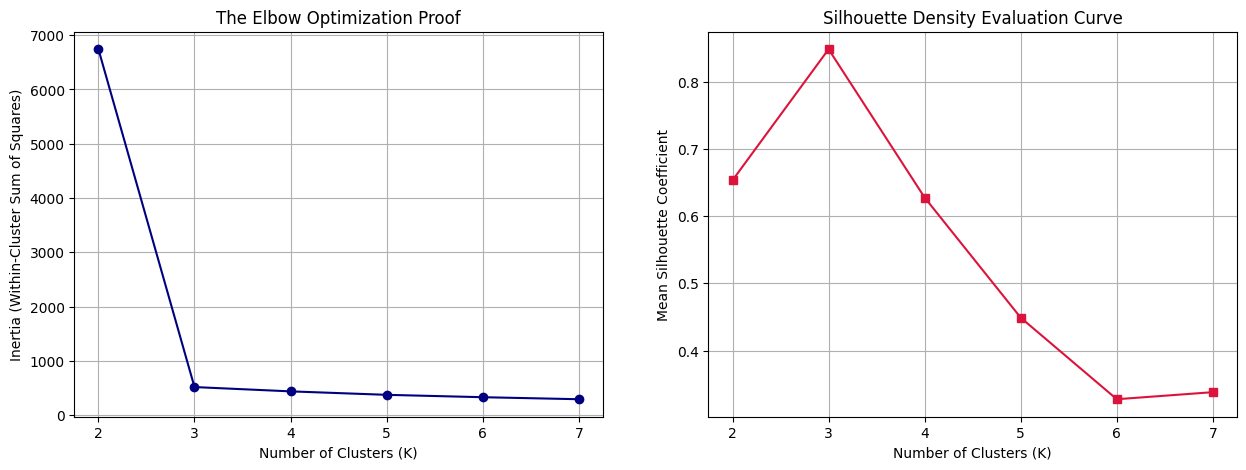


[PERSONAS] Segmenting data into K=3 behavioral boundaries...


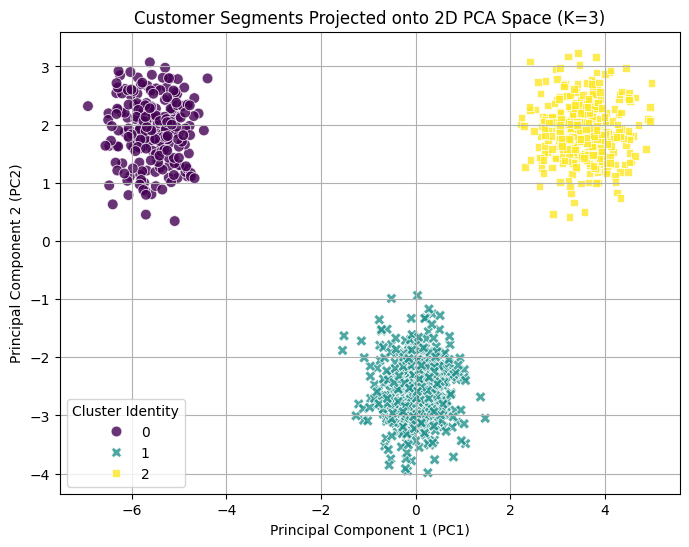


================== 📊 BEHAVIORAL PERSONA PROFILES 📊 ==================
            Spend_Category_1  App_Interaction_1  Annual_Income_USD  \
Cluster_ID                                                           
0                   0.039973          -4.008445       69205.729629   
1                   0.023011           0.001580       68295.432889   
2                   3.448726           0.043396       66628.500996   

            Segment_Size  
Cluster_ID                
0                    224  
1                    427  
2                    349  


In [5]:
#=====================================================================
# MODULE 4: SERVING LAYER & BEHAVIORAL PERSONAS
# =====================================================================
def module_4_generate_personas(df_orig: pd.DataFrame, pca_matrix: np.ndarray, optimal_k: int):
    """
    Executes final grouping model, visualizes localized low-dimensional vectors,
    and returns localized descriptive statistics to formulate operational marketing personas.
    """
    print(f"\n[PERSONAS] Segmenting data into K={optimal_k} behavioral boundaries...")
    kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
    final_labels = kmeans.fit_predict(pca_matrix)

    # Attach labels to original non-scaled workspace to preserve raw interpretability
    df_served = df_orig.copy()
    df_served['Cluster_ID'] = final_labels

    # --- VISUALIZING THE CHOSEN CLUSTERS ---
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        x=pca_matrix[:, 0], y=pca_matrix[:, 1],
        hue=final_labels, palette='viridis', style=final_labels, s=60, alpha=0.8
    )
    plt.title(f'Customer Segments Projected onto 2D PCA Space (K={optimal_k})')
    plt.xlabel('Principal Component 1 (PC1)')
    plt.ylabel('Principal Component 2 (PC2)')
    plt.legend(title='Cluster Identity')
    plt.grid(True)
    plt.show()

    # --- PROFILING CRITICAL METRIC DISTRIBUTIONS FOR BUSINESS MATRICES ---
    print("\n================== 📊 BEHAVIORAL PERSONA PROFILES 📊 ==================")
    profile_summary = df_served.groupby('Cluster_ID')[['Spend_Category_1', 'App_Interaction_1', 'Annual_Income_USD']].mean()
    profile_summary['Segment_Size'] = df_served['Cluster_ID'].value_counts()
    print(profile_summary)
    print("======================================================================")

    return df_served


# ---------------------------------------------------------------------
# PIPELINE EXECUTION LAYER
# ---------------------------------------------------------------------
# Run the pipeline components in succession
X_scaled = module_1_normalize_variance(df_raw)
X_pca, trained_pca = module_2_compress_dimensions(X_scaled, target_components=2)

# Run optimization curves to identify the inflection point
module_3_optimize_k(X_pca, max_k=7)

# The plots demonstrate a clear elbow point and silhouette peak at K=3.
# Let's execute the final segmentation using K=3.
df_final_segments = module_4_generate_personas(df_raw, X_pca, optimal_k=3)